# Predict Customer Churn
**Author:** Mike Johnson <br>
**Date Created:** 2026-07-11 <br>
**Last Updated:** 2026-07-11 <br>
**Objective:** Predict the likelihood of customer churn. <br>
**Data Sources:** https://www.kaggle.com/competitions/playground-series-s6e3/ <br>

***

## 1.0 Setup & Configuration

### 1.1 Import Libraries

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import math
import kagglehub

# Model selection / evaluation
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, RocCurveDisplay,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import optuna

# Preprocessing / pipeline helpers
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

/home/mikej/Projects/kaggle/playground-series-s6e3/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.2 Configuration

In [2]:
RANDOM_STATE = 206
DEV_SIZE = 0.2
TARGET_COL = 'Churn'
DATA_PATH = '../data/'
OUTPUT_PATH = '../submissions/'

## 2.0 Data Loading & Structural Inspection

In [3]:
# Download dataset via kagglehub
path = kagglehub.competition_download(
    'playground-series-s6e3', 
    output_dir = DATA_PATH,
    force_download = True)

print("Path to competition files:", path)

100%|██████████| 14.9M/14.9M [00:00<00:00, 65.1MB/s]

Extracting files...


Path to competition files: ../data/


### 2.1 Training Set

In [4]:
# Load training set
train = pd.read_csv(f'{DATA_PATH}train.csv', index_col = 'id')

# Convert SeniorCitizen to Yes-No like other binaries
train['SeniorCitizen'] = np.where(train['SeniorCitizen'] == 1, 'Yes', 'No')

# Convert Churn to 1-0 binary
train['Churn'] = np.where(train['Churn'] == 'Yes', 1, 0)

print(f'Shape: {train.shape}')
train.head()

Shape: (594194, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,No,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,No,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,No,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,No,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,No,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


In [5]:
# Get info
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  str    
 1   SeniorCitizen     594194 non-null  str    
 2   Partner           594194 non-null  str    
 3   Dependents        594194 non-null  str    
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  str    
 6   MultipleLines     594194 non-null  str    
 7   InternetService   594194 non-null  str    
 8   OnlineSecurity    594194 non-null  str    
 9   OnlineBackup      594194 non-null  str    
 10  DeviceProtection  594194 non-null  str    
 11  TechSupport       594194 non-null  str    
 12  StreamingTV       594194 non-null  str    
 13  StreamingMovies   594194 non-null  str    
 14  Contract          594194 non-null  str    
 15  PaperlessBilling  594194 non-null  str    
 16  PaymentMethod     594194 non-nu

In [6]:
# Describe training set
train.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,594194,2,Female,298738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,594194,2,No,526395,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner,594194,2,Yes,309554,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,594194,2,No,414362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,594194.0,NaN,NaN,NaN,36.577258,25.061922,1.0,12.0,35.0,62.0,72.0
PhoneService,594194,2,Yes,557893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,594194,3,No,283384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,594194,3,Fiber optic,272386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,594194,3,No,289474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,594194,3,No,250083,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 Test Set

In [7]:
# Load test set
test = pd.read_csv(f'{DATA_PATH}test.csv', index_col = 'id')

# Convert SeniorCitizen to Yes-No like other binaries
test['SeniorCitizen'] = np.where(test['SeniorCitizen'] == 1, 'Yes', 'No')

print(f'Shape: {test.shape}')
test.head()

Shape: (254655, 19)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
id,,,,,,,,,,,,,,,,,,,
594194,Female,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
594195,Female,No,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
594196,Male,No,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
594197,Male,No,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
594198,Female,No,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [8]:
# Get info
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 254655 entries, 594194 to 848848
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            254655 non-null  str    
 1   SeniorCitizen     254655 non-null  str    
 2   Partner           254655 non-null  str    
 3   Dependents        254655 non-null  str    
 4   tenure            254655 non-null  int64  
 5   PhoneService      254655 non-null  str    
 6   MultipleLines     254655 non-null  str    
 7   InternetService   254655 non-null  str    
 8   OnlineSecurity    254655 non-null  str    
 9   OnlineBackup      254655 non-null  str    
 10  DeviceProtection  254655 non-null  str    
 11  TechSupport       254655 non-null  str    
 12  StreamingTV       254655 non-null  str    
 13  StreamingMovies   254655 non-null  str    
 14  Contract          254655 non-null  str    
 15  PaperlessBilling  254655 non-null  str    
 16  PaymentMethod     254655 n

In [9]:
# Describe training set
test.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,254655,2,Female,127935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,254655,2,No,225721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner,254655,2,Yes,134703,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,254655,2,No,177016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,254655.0,NaN,NaN,NaN,37.279716,24.777625,1.0,13.0,36.0,62.0,72.0
PhoneService,254655,2,Yes,239173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,254655,3,No,120252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,254655,3,Fiber optic,116731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,254655,3,No,122693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,254655,3,No,105402,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3.0 Train/Dev Split

In [10]:
# Define X and y columns
X = train.drop(columns=[TARGET_COL])
y = train[TARGET_COL]

In [11]:
# Create train and dev sets
X_train, X_dev, y_train, y_dev = train_test_split(
    X, y, 
    test_size=DEV_SIZE, 
    random_state = RANDOM_STATE,
    stratify = y
)

print(f"Train: {X_train.shape}, Dev: {X_dev.shape}, Test: {test.shape}")

Train: (475355, 19), Dev: (118839, 19), Test: (254655, 19)


## 4.0 Exploratory Data Analysis

In [12]:
# Create dataframe for eda
eda = train[train.index.isin(X_train.index)]

### 4.1 Target Variable Analysis

There's a class imbalance in the target variable. I would consider upsamping or downsampling in this case, but a review of the kaggle forums suggest that others didn't get any improvement in model performance.

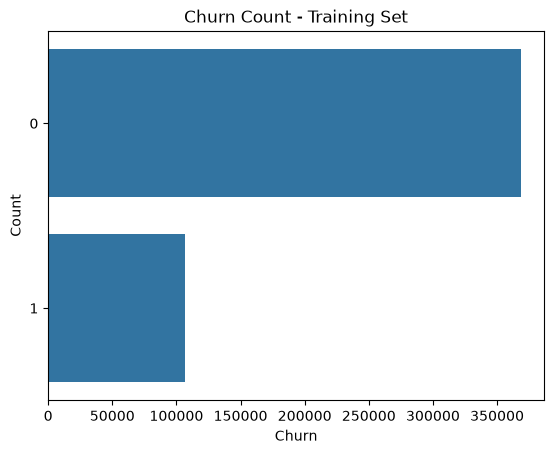

In [13]:
# Visualize counts of each health condition
sns.countplot(eda, y = 'Churn')
plt.title('Churn Count - Training Set')
plt.xlabel('Churn')
plt.ylabel('Count')


plt.show()

### 4.2 Numerical Features

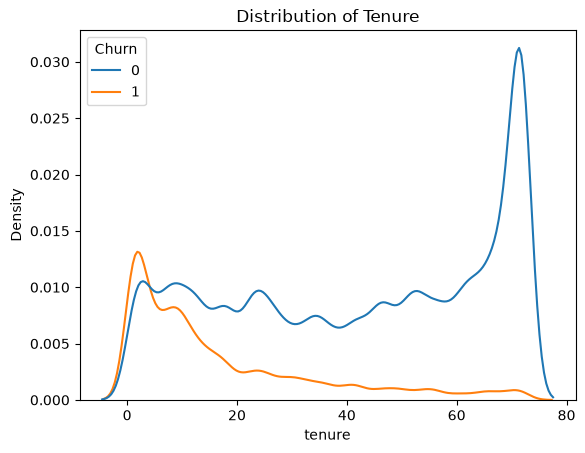

In [14]:
# Visualize distribution of tenure
sns.kdeplot(
    data = eda,
    x = 'tenure',
    hue = 'Churn'
)

plt.title('Distribution of Tenure')
plt.show()

`Churn` is far more likely to occur in early months of a subscription. As the `tenure` ages, that likelihood declines.

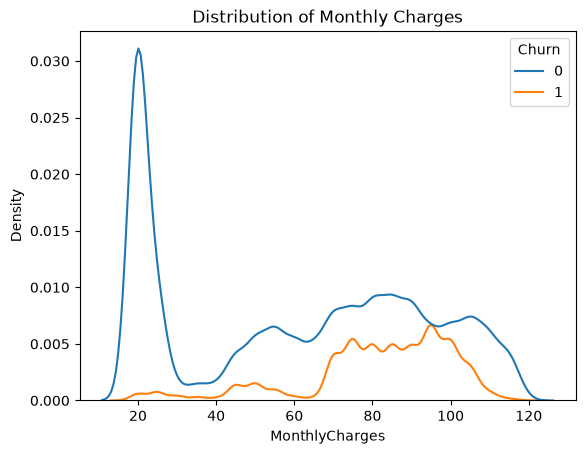

In [15]:
# Visualize distribution of Monthly Charges
sns.kdeplot(
    data = eda,
    x = 'MonthlyCharges',
    hue = 'Churn'
)

plt.title('Distribution of Monthly Charges')
plt.show()

`Churn` is more likely when `MonthlyCharges` are between ~$70 - $100.

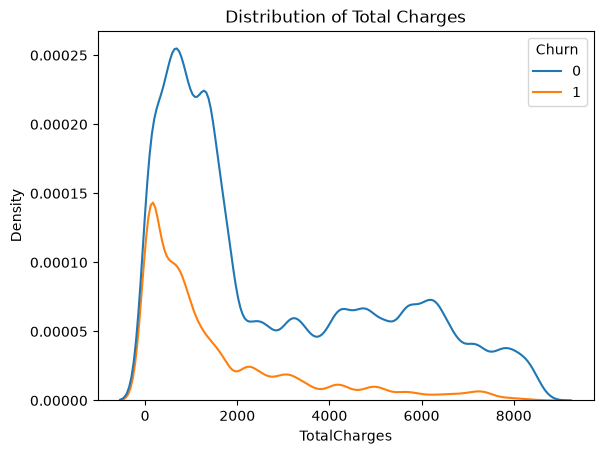

In [16]:
# Visualize distribution of Total Charges
sns.kdeplot(
    data = eda,
    x = 'TotalCharges',
    hue = 'Churn'
)

plt.title('Distribution of Total Charges')
plt.show()

`Churn` is more likely when `TotalCharges` are lower. This aligns with the observations seen in `Tenure`.

### 4.3 Categorical Features

Drivers of `Churn`:
- **Contract type** — Month-to-month customers churn at 42% vs. just 6% (one year) and 1% (two year). This aligns to what was seen the high churn seen in `duration`.
- **Internet service** — Fiber optic customers churn at 41%, versus 10% for DSL and 1% for no internet service. 
- **Payment method** — Electronic check stands out sharply at 49% churn, while the other three methods (bank transfer, credit card, mailed check) cluster around 7-8%. 
- **Add-on services** (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`) — Consistent pattern where customers without these services churn at 38-41%, while those with them churn at only 9-18%. "No internet service" customers barely churn at all (~1%).
- **Senior Citizen** — Seniors churn at 50% vs. 19% for non-seniors, a notable gap.
- **Dependents / Partner** — Customers without dependents (29% vs. 7%) or without a partner (32% vs. 13%) churn considerably more. Suggests single/no-dependent customers are flightier.
- **Paperless Billing** — Paperless customers churn more (32%) than non-paperless (7%) — somewhat counterintuitive, may be confounded with other factors (e.g., month-to-month customers more likely to use paperless billing).

In [17]:
# Define categorical columns
categorical_features = eda.select_dtypes(include=['str']).columns.to_list()

def churn_rate_by(col):
    return eda.groupby(col)['Churn'].mean()

for col in categorical_features:
    print(f"\n--- {col} ---")
    rates = churn_rate_by(col)
    print(rates.map(lambda x: f"{x:.0%}"))


--- gender ---
gender
Female    23%
Male      22%
Name: Churn, dtype: str

--- SeniorCitizen ---
SeniorCitizen
No     19%
Yes    50%
Name: Churn, dtype: str

--- Partner ---
Partner
No     32%
Yes    13%
Name: Churn, dtype: str

--- Dependents ---
Dependents
No     29%
Yes     7%
Name: Churn, dtype: str

--- PhoneService ---
PhoneService
No     17%
Yes    23%
Name: Churn, dtype: str

--- MultipleLines ---
MultipleLines
No                  18%
No phone service    17%
Yes                 28%
Name: Churn, dtype: str

--- InternetService ---
InternetService
DSL            10%
Fiber optic    41%
No              1%
Name: Churn, dtype: str

--- OnlineSecurity ---
OnlineSecurity
No                     41%
No internet service     1%
Yes                     9%
Name: Churn, dtype: str

--- OnlineBackup ---
OnlineBackup
No                     39%
No internet service     1%
Yes                    17%
Name: Churn, dtype: str

--- DeviceProtection ---
DeviceProtection
No                     38%
No i

### 4.4 Missing Values

In [18]:
missing = X_train.isnull().mean().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: float64)

### 4.5 EDA Summary

1. There's a class imbalance in churn. The kaggle forums suggest that there's no improvement to be gained from pursuing downsampling or upsampling.
2. `Churn` is more likely to happen with shorter `tenure` customers. This is backed up by the higher churn see with month-to-month contracts.
3. `MonthlyCharges` sees higher churn around ~$70-$100.
4. Fiber Optic customers are far more likely to churn.
5. Customers paying with electronic check are more likely to churn vs other payment methods.
6. Customers without add-on services are more likely to churn.
7. Senior citizens more likely to churn.
8. Single/no-dependents more likely to churn.
9. Paperless billing customers more likely to churn.

## 5.0 Preprocessing

In [19]:
# Define column groups
numeric_features = X_train.select_dtypes(include=['int', 'float']).columns.to_list()
categorical_features = X_train.select_dtypes(include=['str']).columns.to_list()

In [20]:
# One-hot encode categorical features
categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [21]:
# Combine into a single preprocessor
preprocessor = ColumnTransformer(
    [('cat', categorical_transformer, categorical_features)],
    remainder='passthrough')

## 6.0 Modeling

In [22]:
# Function to make model pipeline
def make_pipeline(model, scale=False):
    """Wrap a model in the preprocessing pipeline."""
    steps = [('preprocessor', preprocessor)]
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)

In [23]:
# Store fitted models and their dev scores for later comparison
models = {}
results = {}


def evaluate(name, model):
    """Fit on the training set, score ROC-AUC on the dev set, record the result,
    and visualize the ROC curve, confusion matrix, and classification report.
    """
    start = time.perf_counter()

    model.fit(X_train, y_train)

    # Predicted probabilities for the positive class (needed for ROC-AUC)
    proba = model.predict_proba(X_dev)[:, 1]
    preds = model.predict(X_dev)

    roc_auc = roc_auc_score(y_dev, proba)
    elapsed = time.perf_counter() - start

    models[name] = model
    results[name] = {'ROC_AUC': roc_auc, 'fit_seconds': elapsed}
    print(f'{name:<22} ROC-AUC = {roc_auc:.4f}   ({elapsed:.1f}s)')
    print(f'\nClassification Report — {name}:')
    print(classification_report(y_dev, preds))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_dev, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1, label='Chance')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'{name}: ROC Curve')
    axes[0].legend(loc='lower right')

    # Confusion matrix
    cm = confusion_matrix(y_dev, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
    axes[1].set_title(f'{name}: Confusion Matrix')

    plt.tight_layout()
    plt.show()

    return model

### 6.1 Model Training

#### 6.1.1 Logistic Regression

Logistic Regression    ROC-AUC = 0.9080   (1.7s)

Classification Report — Logistic Regression:
              precision    recall  f1-score   support

           0       0.96      0.79      0.86     92076
           1       0.55      0.88      0.68     26763

    accuracy                           0.81    118839
   macro avg       0.75      0.83      0.77    118839
weighted avg       0.87      0.81      0.82    118839



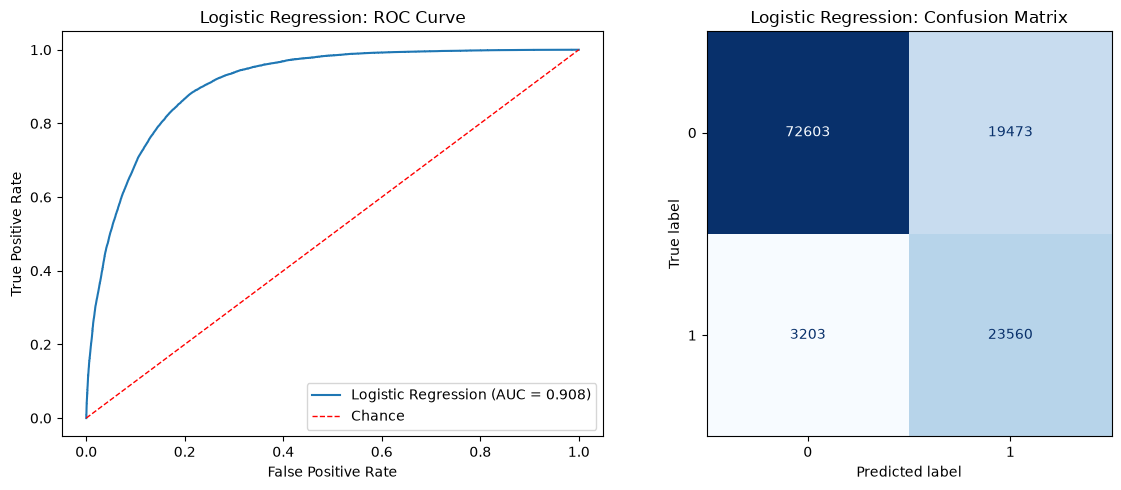

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthroug

In [24]:
evaluate('Logistic Regression', make_pipeline(
    LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    scale=True
))

#### 6.1.2 Random Forest

Random Forest          ROC-AUC = 0.9126   (15.9s)

Classification Report — Random Forest:
              precision    recall  f1-score   support

           0       0.96      0.79      0.87     92076
           1       0.55      0.88      0.68     26763

    accuracy                           0.81    118839
   macro avg       0.76      0.84      0.77    118839
weighted avg       0.87      0.81      0.83    118839



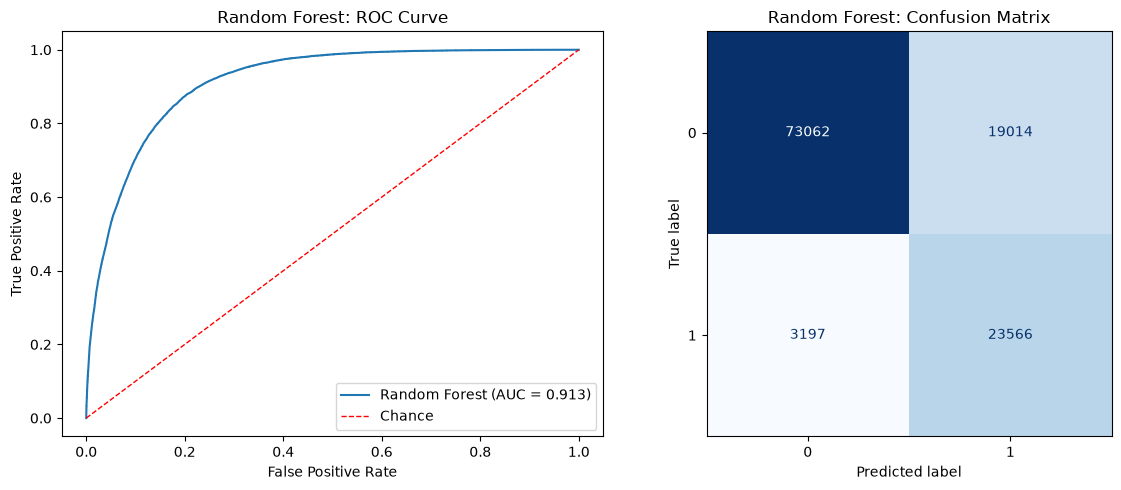

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [25]:
evaluate('Random Forest', make_pipeline(
    RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_leaf=20,
        min_samples_split=10,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
))

#### 6.1.3 LightGBM

[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017369 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567


/home/mikej/Projects/kaggle/playground-series-s6e3/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/mikej/Projects/kaggle/playground-series-s6e3/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM               ROC-AUC = 0.9165   (6.3s)

Classification Report — LightGBM:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     92076
           1       0.72      0.64      0.68     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.80    118839
weighted avg       0.86      0.86      0.86    118839



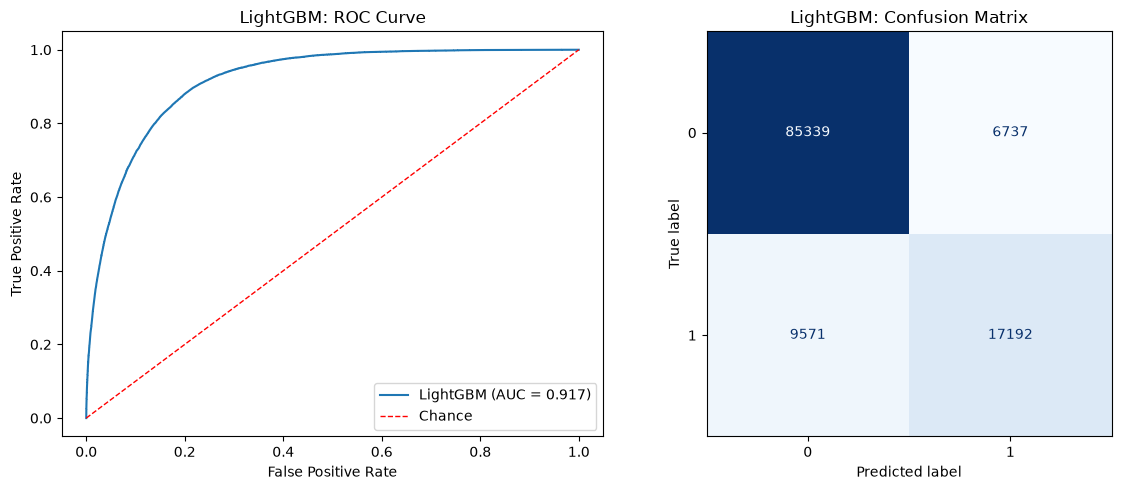

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [26]:
evaluate('LightGBM', make_pipeline(
    LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
))

#### 6.1.4 XGBoost

XGBoost                ROC-AUC = 0.9168   (9.4s)

Classification Report — XGBoost:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     92076
           1       0.72      0.64      0.68     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.80    118839
weighted avg       0.86      0.86      0.86    118839



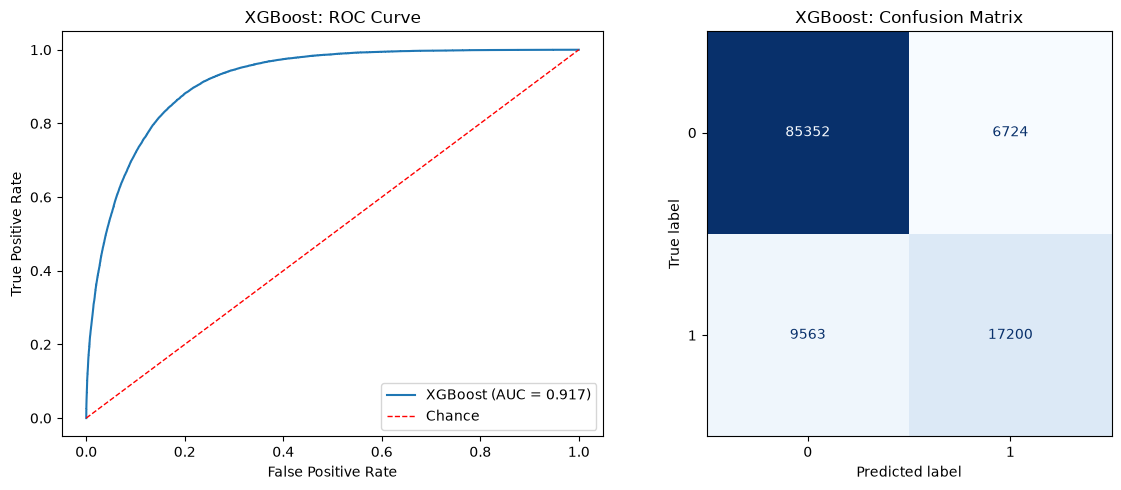

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [27]:
evaluate('XGBoost', make_pipeline(
    XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='auc',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
))

### 6.2 Model Comparison

In [28]:
# Rank models by dev RMSE
leaderboard = round(pd.DataFrame(results).T.sort_values('ROC_AUC', ascending=False),4)
leaderboard

,ROC_AUC,fit_seconds
XGBoost,0.9168,9.3654
LightGBM,0.9165,6.3093
Random Forest,0.9126,15.9158
Logistic Regression,0.9080,1.7462


In [29]:
# Best model
best_name = leaderboard['ROC_AUC'].idxmax()
best_model = models[best_name]

print(f'Selected model: {best_name}')

Selected model: XGBoost


### 6.3 Cross Validation

In [30]:
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(best_model, X_train, y_train, cv=cv, scoring=scoring)

print(f"CV ROC-AUC:   {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"CV Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"CV Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"CV Recall:    {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"CV F1:        {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")

CV ROC-AUC:   0.9162 ± 0.0008
CV Accuracy:  0.8610 ± 0.0005
CV Precision: 0.7118 ± 0.0029
CV Recall:    0.6437 ± 0.0034
CV F1:        0.6760 ± 0.0011


### 6.4 Hyperparameter Tuning

In [31]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
    }

    model = make_pipeline(XGBClassifier(**params))

    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best ROC-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-07-11 15:42:57,981] A new study created in memory with name: no-name-a547e1dd-ad31-4f4d-8f26-3cca4af4f43d
[I 2026-07-11 15:43:10,684] Trial 0 finished with value: 0.9160333941374205 and parameters: {'n_estimators': 515, 'learning_rate': 0.04632085048874105, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.9708870053573219, 'colsample_bytree': 0.7731286055135114, 'reg_alpha': 0.6474160974864621, 'reg_lambda': 1.6560408533232067, 'gamma': 0.2865714516013942}. Best is trial 0 with value: 0.9160333941374205.
[I 2026-07-11 15:43:32,114] Trial 1 finished with value: 0.9160134299444502 and parameters: {'n_estimators': 736, 'learning_rate': 0.03102659621936957, 'max_depth': 7, 'min_child_weight': 9, 'subsample': 0.6996107894366701, 'colsample_bytree': 0.8797462321204648, 'reg_alpha': 0.09514671102013306, 'reg_lambda': 1.8372797255195528, 'gamma': 0.47328012803971353}. Best is trial 0 with value: 0.9160333941374205.
[I 2026-07-11 15:43:55,763] Trial 2 finished with value: 0.9162625

Best ROC-AUC: 0.9164
Best params: {'n_estimators': 1324, 'learning_rate': 0.08228854879908862, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.9342366340706131, 'colsample_bytree': 0.8814441467267067, 'reg_alpha': 0.522877067675758, 'reg_lambda': 0.17059821490460608, 'gamma': 0.2635967650706784}


In [32]:
# Make final model
final_model = make_pipeline(XGBClassifier(**study.best_params, random_state=RANDOM_STATE, n_jobs=-1))
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

## 7.0 Model Evaluation

XGBoost                ROC-AUC = 0.9168   (5.9s)

Classification Report — XGBoost:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     92076
           1       0.72      0.64      0.68     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.80    118839
weighted avg       0.86      0.86      0.86    118839



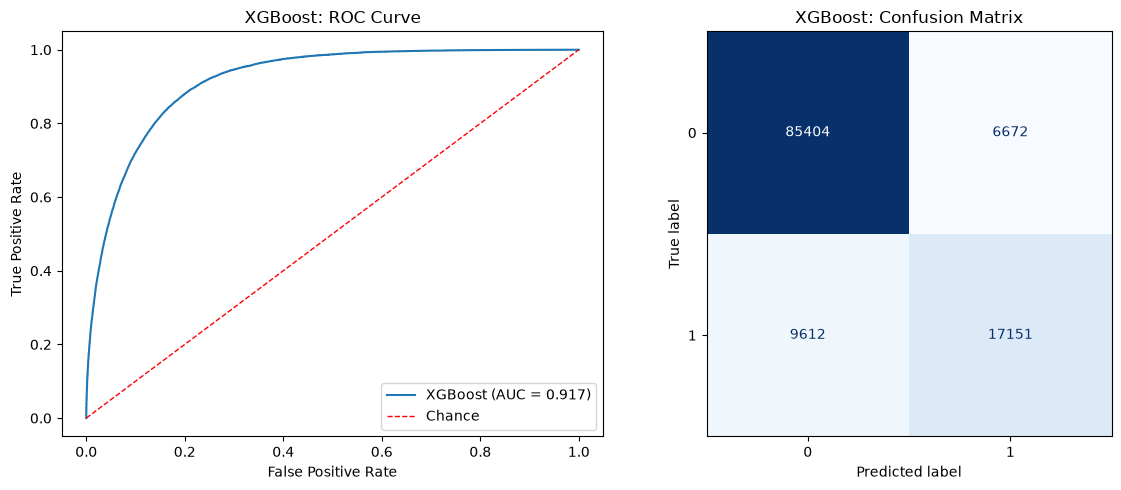

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [33]:
evaluate('XGBoost', make_pipeline(
    XGBClassifier(
        **study.best_params,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
))

### 7.1 Feature Importance

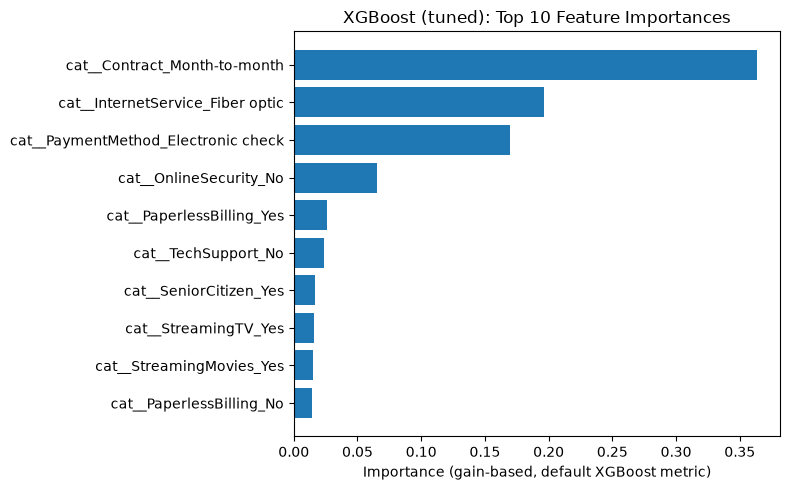

In [34]:
xgb_model = final_model.named_steps['model']
preprocessor_fitted = final_model.named_steps['preprocessor']

feature_names = preprocessor_fitted.get_feature_names_out()
importances = xgb_model.feature_importances_

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# Keep only the top 10 by importance
imp_df = imp_df.sort_values('importance', ascending=False).head(10)
imp_df = imp_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['feature'], imp_df['importance'])
ax.set_xlabel('Importance (gain-based, default XGBoost metric)')
ax.set_title('XGBoost (tuned): Top 10 Feature Importances')
plt.tight_layout()
plt.show()

## 8.0 Make Predictions

In [35]:
# Make predictions on test set
y_pred = final_model.predict_proba(test)[:, 1]

# Build submission file
submission = pd.DataFrame({
    'id': test.index,
    'Churn': y_pred
})

submission.to_csv(f'{OUTPUT_PATH}submission.csv', index=False)